In [38]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

batch_size = 2

# 单词表大小
max_num_src_words = 8
max_num_tgt_words = 8
model_dim = 8

# 序列最大长度（non-used）
max_src_seq_len = 5
max_tgt_seq_len = 5

# src_len = torch.randint(2, 5, (batch_size,))
# tgt_len = torch.randint(2, 5, (batch_size,))
src_len = torch.Tensor([2, 4]).to(torch.int32)
tgt_len = torch.Tensor([4, 3]).to(torch.int32)

# 改成stack简洁一点
# src_seq = torch.cat([torch.unsqueeze(F.pad(torch.randint(1, max_num_src_words, (L,)), (0, max_src_seq_len-L)), 0) for L in src_len])
src_seq = torch.stack([F.pad(torch.randint(1, max_num_src_words, (L,)), (0, max(src_len)-L)) for L in src_len])
tgt_seq = torch.stack([F.pad(torch.randint(1, max_num_tgt_words, (L,)), (0, max(src_len)-L)) for L in tgt_len])

print(src_seq)
print(tgt_seq)

tensor([[2, 1, 0, 0],
        [3, 1, 2, 3]])
tensor([[4, 3, 4, 3],
        [5, 5, 7, 0]])


### 1. 构造Embedding
`torch.nn.Embedding`：构建时`num_embeddings=max_words_num+1` ，也就是要预留一个<PAD>位置。本质是对句子的每个词构建了一个查表矩阵（Embedding.weight），然后在表示句子时就可以用对应的索引来表示每个词，对于长度不够的句子空缺处就用0填充，表示用矩阵中下标为0的向量来填充。
- 当一个句子中的两个词相同时，它们在矩阵中对应的值也会相同，这个时候就需要对Embedding做进一步处理了，比如加入位置编码。

In [12]:
# 构建Embedding
model_dim = 8
src_embedding_table = nn.Embedding(max_num_src_words+1, model_dim)
tgt_embedding_table = nn.Embedding(max_num_tgt_words+1, model_dim)
src_embedding = src_embedding_table(src_seq)
tgt_embedding = tgt_embedding_table(tgt_seq)

# print(src_embedding_table.weight)
# print(src_seq)
# print(src_embedding) 


### 2. 构造Position Embedding
对每一个词构建一个长度为`model_dim`的向量来表示其位置信息，最终目标就是构建一个`(max_position_len, model_dim)`的矩阵。

具体公式如下，作者的实现思路是分奇偶列按列赋值：
1. 首先sin,cos括号内部的值其实是一样的，所以先计算括号内部值。可以看成`pos`矩阵除以后面这部分的矩阵，`pos`为行下标，`2i`是偶数的列标，然后利用广播机制将两者相除。
    - `pos_mat`的形状是`(max_position_len, 1)`，代表行向量
    - `i_mat`的形状是`(1, model_dim)`，代表分母项
    - 两者相除PyTorch 利用广播机制生成了一个 `(max_position_len, model_dim)` 的矩阵，其中第 $j$ 行第 $k$ 列的值正好对应了 $\frac{pos_j}{10000^{2k / d_{model}}}$
2. 得到括号内部的值，再根据奇偶列标分别在外部添加`sin`或`cos`，分别赋值给对应的列

$$
\begin{aligned}
PE_{(pos, 2i)} &= \sin(pos / 10000^{2i/d_{\text{model}}}) \\
PE_{(pos, 2i+1)} &= \cos(pos / 10000^{2i/d_{\text{model}}})
\end{aligned}
$$

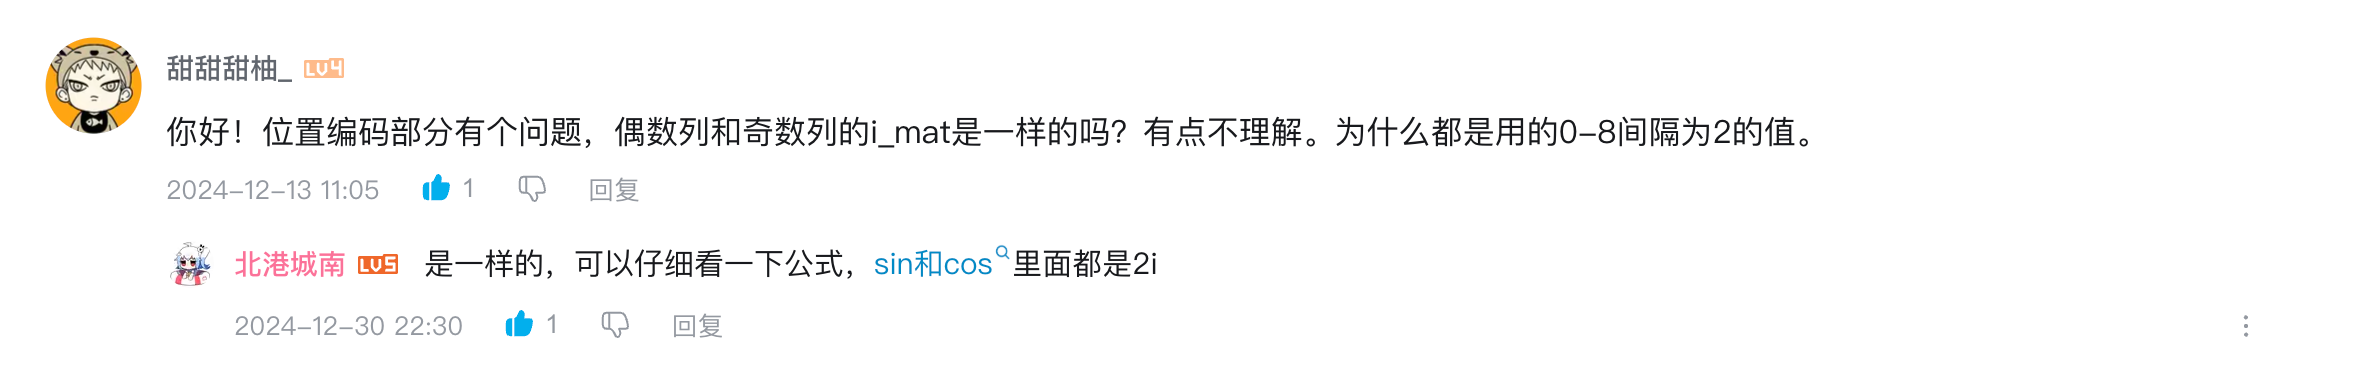

In [ ]:
# 构造Position Embedding
max_position_len = 5
pos_mat = torch.arange(max_position_len).reshape((-1, 1))
i_mat = torch.pow(10000, (torch.arange(0, model_dim, 2).reshape((1, -1)) / model_dim))

# print(pos_mat.shape, i_mat.shape)
# print((pos_mat / i_mat).shape)

pe_embedding_table = torch.zeros(max_position_len, model_dim)
pe_embedding_table[:, 0::2] = torch.sin(pos_mat / i_mat)
pe_embedding_table[:, 1::2] = torch.cos(pos_mat / i_mat)

pe_embedding = nn.Embedding(max_position_len, model_dim)
pe_embedding.weight = nn.Parameter(pe_embedding_table, requires_grad=False)

# 传入位置信息
# src_pos = torch.stack([torch.arange(max_src_seq_len) for _ in src_len])
# tgt_pos = torch.stack([torch.arange(max_src_seq_len) for _ in tgt_len])
# 以下是作者的原写法
src_pos = torch.stack([torch.arange(max(src_len)) for _ in src_len])
tgt_pos = torch.stack([torch.arange(max(tgt_len)) for _ in tgt_len])
# print(src_pos)
# print(tgt_pos)

src_pe_embedding = pe_embedding(src_pos)
tgt_pe_embedding = pe_embedding(tgt_pos)
# print(pe_embedding_table)
# print(src_pe_embedding)

对于作者上面的代码，我有几处疑问，通过问AI勉强理解了，但是并不敢说理解透彻，所以在这里就只把我的问题列出来，不给出我的想法了。
1. src_pos = torch.stack([torch.arange(max(src_len)) for _ in src_len])，这一行代码我觉得参数传错了，具体看我的注释。</br>
    **视频后面作者把全部相关padding参数都改成了`max(src_len)`**
2. 为什么要额外定义一个embedding，把pe_embedding_table作为权重传入？pe_embedding_table不就已经是位置编码表了吗？
3. src_pe_embedding = pe_embedding(src_pos)这一步调用又是何意味？

### 3. 构建encoder的self-attention mask
目标是不让padding的值参与注意力分数的计算，具体来说就是把与padding相关的位置的注意力分数设置成`-inf`，这样经过`softmax`后对应值就会变得无限接近0。
- 为什么第一个batch的prob矩阵后两行会是0.25：因为后两行pading后全是`-1e9`，按行计算softmax就会都是等分概率，也就是`1/4=0.25`。但是这不影响训练，因为在计算损失时还会根据mask屏蔽对应位置的损失。

In [44]:
valid_encoder_pos = torch.unsqueeze(torch.stack([F.pad(torch.ones(L), (0, max(src_len)-L)) for L in src_len]), 2)
valid_encoder_pos_mat = torch.bmm(valid_encoder_pos, valid_encoder_pos.transpose(1, 2))
invalid_encoder_pos_mat = 1 - valid_encoder_pos_mat
mask_encoder_self_attention = invalid_encoder_pos_mat.to(torch.bool)

score = torch.randn(batch_size, max(src_len), max(src_len))
masked_score = score.masked_fill(mask_encoder_self_attention, -1e9)
prob = F.softmax(masked_score, -1)

print(score)
print(masked_score)
print(prob)


tensor([[[ 1.0176, -0.3835, -0.4999,  0.3256],
         [-1.2055, -1.0577,  0.9232, -1.0607],
         [-1.2743,  0.0321,  0.9790,  1.5435],
         [-1.4956,  1.7814, -0.8905,  0.5768]],

        [[-0.9373,  0.3098, -3.2025, -1.7200],
         [-1.8623,  0.0998,  1.1438,  0.7083],
         [-0.8176,  0.7395,  0.3288, -1.0361],
         [ 0.5988, -0.3162,  1.9623, -0.4145]]])
tensor([[[ 1.0176e+00, -3.8346e-01, -1.0000e+09, -1.0000e+09],
         [-1.2055e+00, -1.0577e+00, -1.0000e+09, -1.0000e+09],
         [-1.0000e+09, -1.0000e+09, -1.0000e+09, -1.0000e+09],
         [-1.0000e+09, -1.0000e+09, -1.0000e+09, -1.0000e+09]],

        [[-9.3733e-01,  3.0979e-01, -3.2025e+00, -1.7200e+00],
         [-1.8623e+00,  9.9845e-02,  1.1438e+00,  7.0833e-01],
         [-8.1759e-01,  7.3953e-01,  3.2880e-01, -1.0361e+00],
         [ 5.9880e-01, -3.1620e-01,  1.9623e+00, -4.1445e-01]]])
tensor([[[0.8023, 0.1977, 0.0000, 0.0000],
         [0.4631, 0.5369, 0.0000, 0.0000],
         [0.2500, 0.2500, 